Loads the crash dataset and weather dataset into Python\.

In [1]:
import pandas as pd

crash_df = pd.read_csv("dataset_crash.csv", low_memory=False)
weather_df = pd.read_csv("dataset_weather.csv")

# Make sure both date columns are datetime
crash_df["date"] = pd.to_datetime(crash_df["date"])
weather_df["date"] = pd.to_datetime(weather_df["date"])

# Make sure hour is numeric
crash_df["hour"] = pd.to_numeric(crash_df["hour"], errors="coerce")
weather_df["hour"] = pd.to_numeric(weather_df["hour"], errors="coerce")

# Merge
merged_df = crash_df.merge(
    weather_df,
    on=["date", "hour"],
    how="left"
)

print(merged_df.head())
print(merged_df.shape)

   CRASH DATE           CRASH TIME   BOROUGH ZIP CODE   LATITUDE  LONGITUDE  \
0  2023-11-01  1900-01-01 01:29:00  brooklyn  11230.0  40.621790 -73.970024   
1  2021-09-11  1900-01-01 09:35:00  brooklyn  11208.0  40.667202 -73.866500   
2  2021-12-14  1900-01-01 08:13:00  brooklyn  11233.0  40.683304 -73.917274   
3  2021-12-14  1900-01-01 17:05:00  brooklyn      NaN  40.709183 -73.956825   
4  2021-12-14  1900-01-01 08:17:00     bronx  10475.0  40.868160 -73.831480   

                      LOCATION  NUMBER OF PERSONS INJURED  \
0       (40.62179, -73.970024)                        1.0   
1        (40.667202, -73.8665)                        0.0   
2      (40.683304, -73.917274)                        0.0   
3      (40.709183, -73.956825)                        0.0   
4        (40.86816, -73.83148)                        2.0   

   NUMBER OF PERSONS KILLED  NUMBER OF PEDESTRIANS INJURED  ...  year  MONTH  \
0                       0.0                              0  ...  2023     11  

In [2]:
crash_df.head()

,CRASH DATE,CRASH TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,LOCATION,NUMBER OF PERSONS INJURED,NUMBER OF PERSONS KILLED,NUMBER OF PEDESTRIANS INJURED,...,CONTRIBUTING FACTOR VEHICLE 1,CONTRIBUTING FACTOR VEHICLE 2,CONTRIBUTING FACTOR VEHICLE 3,VEHICLE TYPE CODE 1,VEHICLE TYPE CODE 2,VEHICLE TYPE CODE 3,date,year,MONTH,hour
0,2023-11-01,1900-01-01 01:29:00,brooklyn,11230.0,40.621790,-73.970024,"(40.62179, -73.970024)",1.0,0.0,0,...,Unspecified,Unspecified,Unspecified,Moped,Sedan,Sedan,2023-11-01,2023,11,1
1,2021-09-11,1900-01-01 09:35:00,brooklyn,11208.0,40.667202,-73.866500,"(40.667202, -73.8665)",0.0,0.0,0,...,Unspecified,NaN,NaN,Sedan,NaN,NaN,2021-09-11,2021,9,9
2,2021-12-14,1900-01-01 08:13:00,brooklyn,11233.0,40.683304,-73.917274,"(40.683304, -73.917274)",0.0,0.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,2021-12-14,2021,12,8
3,2021-12-14,1900-01-01 17:05:00,brooklyn,NaN,40.709183,-73.956825,"(40.709183, -73.956825)",0.0,0.0,0,...,Passing Too Closely,Unspecified,NaN,Sedan,Tractor Truck Diesel,NaN,2021-12-14,2021,12,17
4,2021-12-14,1900-01-01 08:17:00,bronx,10475.0,40.868160,-73.831480,"(40.86816, -73.83148)",2.0,0.0,0,...,Unspecified,Unspecified,NaN,Sedan,Sedan,NaN,2021-12-14,2021,12,8


In [3]:
weather_df.head()

,date,hour,season,temperature_2m (°C),relative_humidity_2m (%),rain (mm),snowfall (cm),cloud_cover (%),wind_speed_10m (km/h)
0,2015-01-01,0,winter,-4.0,49.0,0.0,0.0,0.0,14.1
1,2015-01-01,1,winter,-4.0,49.0,0.0,0.0,0.0,14.1
2,2015-01-01,2,winter,-4.2,52.0,0.0,0.0,0.0,14.7
3,2015-01-01,3,winter,-4.2,52.0,0.0,0.0,0.0,15.6
4,2015-01-01,4,winter,-4.2,50.0,0.0,0.0,0.0,16.1


Converts crash date into datetime format
Extracts the hour of the crash

In [4]:
print(crash_df.columns)
print(weather_df.columns)

Index(['CRASH DATE', 'CRASH TIME', 'BOROUGH', 'ZIP CODE', 'LATITUDE',
       'LONGITUDE', 'LOCATION', 'NUMBER OF PERSONS INJURED',
       'NUMBER OF PERSONS KILLED', 'NUMBER OF PEDESTRIANS INJURED',
       'NUMBER OF PEDESTRIANS KILLED', 'NUMBER OF CYCLIST INJURED',
       'NUMBER OF CYCLIST KILLED', 'NUMBER OF MOTORIST INJURED',
       'NUMBER OF MOTORIST KILLED', 'CONTRIBUTING FACTOR VEHICLE 1',
       'CONTRIBUTING FACTOR VEHICLE 2', 'CONTRIBUTING FACTOR VEHICLE 3',
       'VEHICLE TYPE CODE 1', 'VEHICLE TYPE CODE 2', 'VEHICLE TYPE CODE 3',
       'date', 'year', 'MONTH', 'hour'],
      dtype='object')
Index(['date', 'hour', 'season', 'temperature_2m (°C)',
       'relative_humidity_2m (%)', 'rain (mm)', 'snowfall (cm)',
       'cloud_cover (%)', 'wind_speed_10m (km/h)'],
      dtype='object')


In [5]:
crash_df = crash_df.loc[:, ~crash_df.columns.duplicated()]

In [6]:
print(crash_df.columns)

Index(['CRASH DATE', 'CRASH TIME', 'BOROUGH', 'ZIP CODE', 'LATITUDE',
       'LONGITUDE', 'LOCATION', 'NUMBER OF PERSONS INJURED',
       'NUMBER OF PERSONS KILLED', 'NUMBER OF PEDESTRIANS INJURED',
       'NUMBER OF PEDESTRIANS KILLED', 'NUMBER OF CYCLIST INJURED',
       'NUMBER OF CYCLIST KILLED', 'NUMBER OF MOTORIST INJURED',
       'NUMBER OF MOTORIST KILLED', 'CONTRIBUTING FACTOR VEHICLE 1',
       'CONTRIBUTING FACTOR VEHICLE 2', 'CONTRIBUTING FACTOR VEHICLE 3',
       'VEHICLE TYPE CODE 1', 'VEHICLE TYPE CODE 2', 'VEHICLE TYPE CODE 3',
       'date', 'year', 'MONTH', 'hour'],
      dtype='object')


Converts weather dates into datetime format so they match crash data\.

In [7]:
weather_df["date"] = pd.to_datetime(weather_df["date"])

Renames crash columns so they match the weather dataset columns\.
This allows merging\.

Combines crash data with weather data based on date and hour\.
Now each crash observation has associated weather conditions\.

In [8]:
merged_df = crash_df.merge(
    weather_df,
    on=["date", "hour"],
    how="left"
)

Creates rain intensity categories:No rainLight rainModerate rainHeavy rainThen calculates injuries by rain level\.

In [9]:
merged_df["rain_category"] = pd.cut(
    merged_df["rain (mm)"],
    bins=[-0.1, 0, 2, 10, 100],
    labels=["No Rain", "Light Rain", "Moderate Rain", "Heavy Rain"]
)

merged_df.groupby("rain_category")["NUMBER OF PERSONS INJURED"].mean()

/tmp/ipykernel_219/1013076274.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  merged_df.groupby("rain_category")["NUMBER OF PERSONS INJURED"].mean()


rain_category
No Rain          0.348030
Light Rain       0.352401
Moderate Rain    0.369935
Heavy Rain       0.410871
Name: NUMBER OF PERSONS INJURED, dtype: float64

Creates a bar chart showing average injuries by rain intensity\.

/tmp/ipykernel_219/255610751.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("rain_category")["NUMBER OF PERSONS INJURED"]


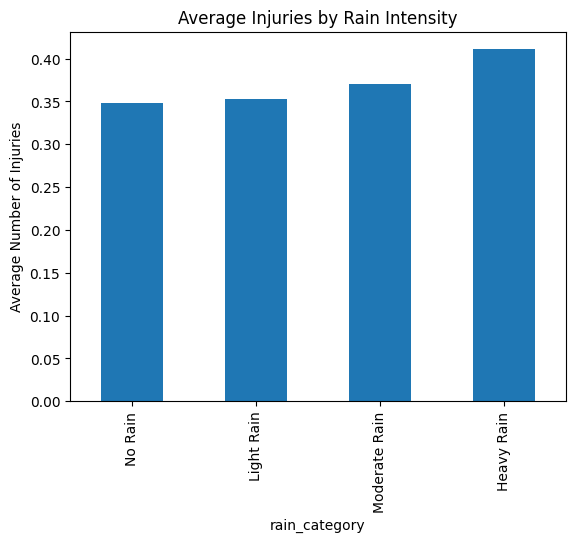

In [10]:
import matplotlib.pyplot as plt

rain_injury = (
    merged_df
    .groupby("rain_category")["NUMBER OF PERSONS INJURED"]
    .mean()
)

rain_injury.plot(kind="bar")
plt.title("Average Injuries by Rain Intensity")
plt.ylabel("Average Number of Injuries")
plt.show()

Defines a severe crash indicator if:
\- someone was killed OR
\- ≥2 people were injured\.

In [11]:
merged_df["severe_crash"] = (
    (merged_df["NUMBER OF PERSONS KILLED"] > 0) |
    (merged_df["NUMBER OF PERSONS INJURED"] >= 2)
)

merged_df.groupby("rain_category")["severe_crash"].mean()

/tmp/ipykernel_219/268972734.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  merged_df.groupby("rain_category")["severe_crash"].mean()


rain_category
No Rain          0.058315
Light Rain       0.057621
Moderate Rain    0.061615
Heavy Rain       0.076358
Name: severe_crash, dtype: float64

Creates a variable indicating whether snow occurred\.

In [12]:
merged_df["snow_event"] = merged_df["snowfall (cm)"] > 0

Bar chart of injuries during snow vs no snow\.

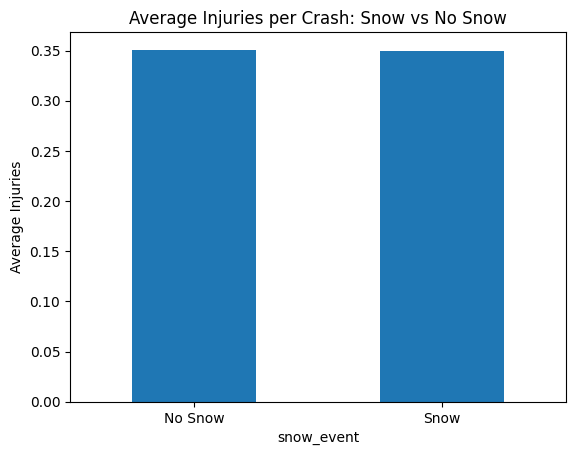

In [13]:
injury_avg = merged_df.groupby("snow_event")["NUMBER OF PERSONS INJURED"].mean()

injury_avg.plot(kind="bar")
plt.title("Average Injuries per Crash: Snow vs No Snow")
plt.xticks([0,1], ["No Snow", "Snow"], rotation=0)
plt.ylabel("Average Injuries")
plt.show()

Probability of severe crash during snow\.

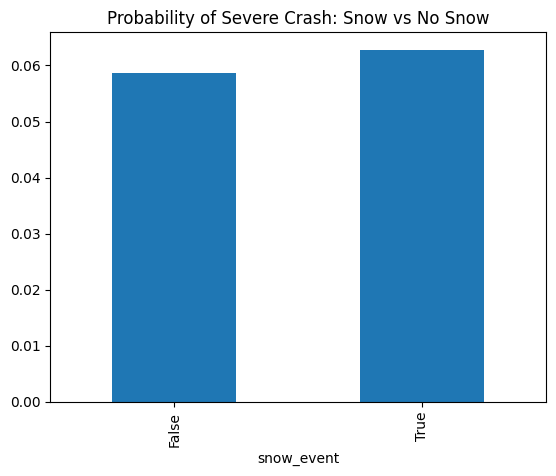

In [14]:
merged_df["severe"] = (
    (merged_df["NUMBER OF PERSONS KILLED"] > 0) |
    (merged_df["NUMBER OF PERSONS INJURED"] >= 2)
)

severity_rate = merged_df.groupby("snow_event")["severe"].mean()
severity_rate.plot(kind="bar")
plt.title("Probability of Severe Crash: Snow vs No Snow")
plt.show()

Adds year column\.

In [15]:
weather_df["year"] = weather_df["date"].dt.year
merged_df["year"] = merged_df["date"].dt.year

Shows how crash rates change over time\.

In [16]:
yearly_weather = (
    weather_df
    .groupby(["year"])
    .agg(
        snow_hours=("snowfall (cm)", lambda x: (x > 0).sum()),
        no_snow_hours=("snowfall (cm)", lambda x: (x == 0).sum())
    )
    .reset_index()
)

In [17]:
yearly_crashes = (
    merged_df
    .groupby(["year"])
    .agg(
        snow_crashes=("snowfall (cm)", lambda x: (x > 0).sum()),
        no_snow_crashes=("snowfall (cm)", lambda x: (x == 0).sum())
    )
    .reset_index()
)

In [18]:
yearly = yearly_weather.merge(yearly_crashes, on="year")

yearly["snow_rate"] = yearly["snow_crashes"] / yearly["snow_hours"]
yearly["no_snow_rate"] = yearly["no_snow_crashes"] / yearly["no_snow_hours"]

yearly.head()

,year,snow_hours,no_snow_hours,snow_crashes,no_snow_crashes,snow_rate,no_snow_rate
0,2015,531,8503,9158,177087,17.246704,20.826414
1,2016,432,8631,8597,206165,19.900463,23.886572
2,2017,435,8610,10593,217259,24.351724,25.233333
3,2018,456,8577,11113,215753,24.370614,25.154833
4,2019,410,8612,8641,194550,21.075610,22.590571


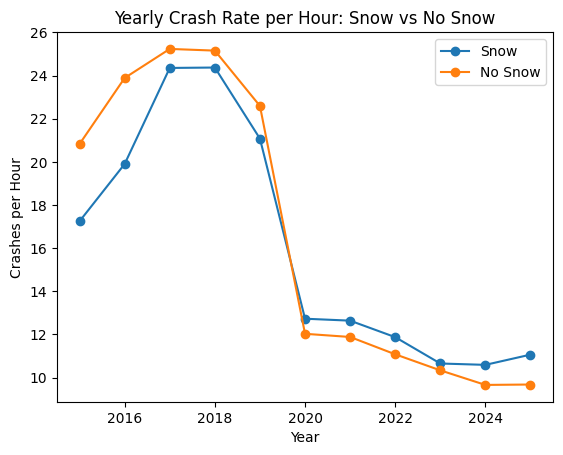

In [19]:
import matplotlib.pyplot as plt

plt.plot(yearly["year"], yearly["snow_rate"], marker="o", label="Snow")
plt.plot(yearly["year"], yearly["no_snow_rate"], marker="o", label="No Snow")

plt.title("Yearly Crash Rate per Hour: Snow vs No Snow")
plt.xlabel("Year")
plt.ylabel("Crashes per Hour")
plt.legend()
plt.show()

Creates temperature categories\.

In [20]:
weather_df["temp_category"] = pd.cut(
    weather_df["temperature_2m (°C)"],
    bins=[-30,0,10,20,40],
    labels=["Below 0°C","0–10°C","10–20°C","Above 20°C"]
)

Avoids bias by normalizing with weather exposure\.

In [21]:
weather_hours = weather_df.groupby("temp_category").size()

/tmp/ipykernel_219/304052453.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  weather_hours = weather_df.groupby("temp_category").size()


In [22]:
merged_df["temp_category"] = pd.cut(
    merged_df["temperature_2m (°C)"],
    bins=[-30, 0, 10, 20, 40],
    labels=["Below 0°C", "0–10°C", "10–20°C", "Above 20°C"]
)

crash_counts = merged_df.groupby("temp_category").size()
crash_counts

/tmp/ipykernel_219/275025958.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  crash_counts = merged_df.groupby("temp_category").size()


temp_category
Below 0°C     160184
0–10°C        480089
10–20°C       465803
Above 20°C    521721
dtype: int64

In [23]:
crash_rate = crash_counts / weather_hours

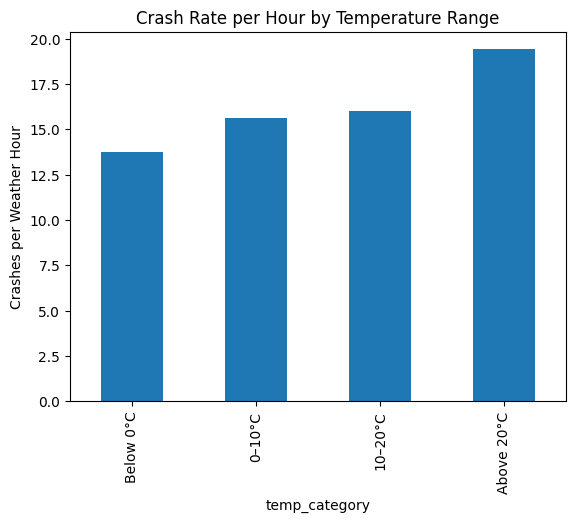

In [24]:
crash_rate.plot(kind="bar")
plt.title("Crash Rate per Hour by Temperature Range")
plt.ylabel("Crashes per Weather Hour")
plt.show()

/tmp/ipykernel_219/2435850807.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  severity_temp = merged_df.groupby("temp_category")["NUMBER OF PERSONS INJURED"].mean()


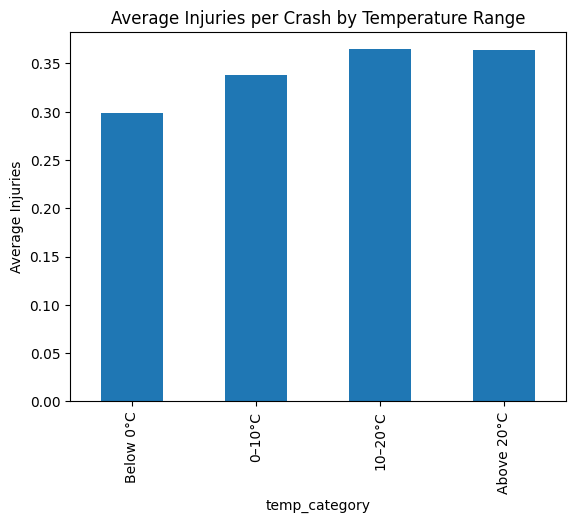

In [25]:
severity_temp = merged_df.groupby("temp_category")["NUMBER OF PERSONS INJURED"].mean()

severity_temp.plot(kind="bar")
plt.title("Average Injuries per Crash by Temperature Range")
plt.ylabel("Average Injuries")
plt.show()

Creates night indicator\.

In [26]:
merged_df["night"] = merged_df["hour"].apply(lambda x: 1 if x >= 20 or x <= 5 else 0)

This directly tests your literature claim\.

In [27]:
merged_df.groupby(["snow_event","night"])["severe_crash"].mean()

snow_event  night
False       0        0.051560
            1        0.078792
True        0        0.039496
            1        0.072683
Name: severe_crash, dtype: float64

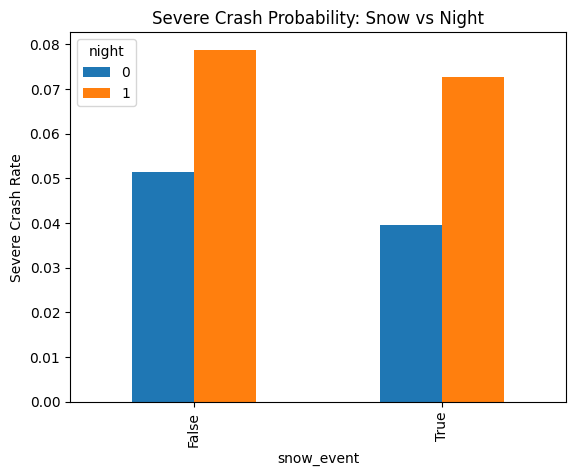

In [28]:
night_weather = merged_df.groupby(["snow_event","night"])["severe_crash"].mean().unstack()

night_weather.plot(kind="bar")
plt.title("Severe Crash Probability: Snow vs Night")
plt.ylabel("Severe Crash Rate")
plt.show()

Wind speed category vs injuries\.
This tests vehicle stability effects\.

In [29]:
merged_df["wind_category"] = pd.cut(
    merged_df["wind_speed_10m (km/h)"],
    bins=[0,10,20,40,80],
    labels=["Low","Moderate","High","Very High"]
)

merged_df.groupby("wind_category")["NUMBER OF PERSONS INJURED"].mean()

/tmp/ipykernel_219/4030849550.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  merged_df.groupby("wind_category")["NUMBER OF PERSONS INJURED"].mean()


wind_category
Low          0.360106
Moderate     0.349550
High         0.328605
Very High    0.277159
Name: NUMBER OF PERSONS INJURED, dtype: float64

In [30]:
merged_df["year"] = merged_df["date"].dt.year

injuries_per_year = (
    merged_df.groupby("year")["NUMBER OF PERSONS INJURED"]
    .sum()
    .reset_index()
)

injuries_per_year

,year,NUMBER OF PERSONS INJURED
0,2015,44490.0
1,2016,56675.0
2,2017,60349.0
3,2018,61187.0
4,2019,59154.0
5,2020,43289.0
6,2021,50533.0
7,2022,50074.0
8,2023,52460.0
9,2024,52026.0


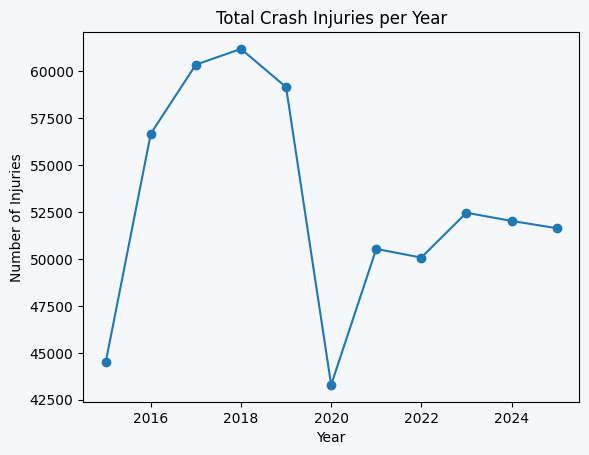

In [31]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

# Set background color
fig.patch.set_facecolor("#f6f7fa")
ax.set_facecolor("#f6f7fa")

ax.plot(
    injuries_per_year["year"],
    injuries_per_year["NUMBER OF PERSONS INJURED"],
    marker="o"
)

ax.set_title("Total Crash Injuries per Year")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Injuries")

plt.show()

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

# create season from MONTH
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Fall"

crash_df["season"] = crash_df["MONTH"].apply(get_season)

days_per_season = crash_df.groupby("season")["CRASH DATE"].nunique()
print(days_per_season)

season
Fall      1001
Spring    1012
Summer    1012
Winter     993
Name: CRASH DATE, dtype: int64


In [38]:
season_stats = crash_df.groupby("season").agg(
    crashes=("CRASH DATE", "count"),
    injuries=("NUMBER OF PERSONS INJURED", "sum"),
    days=("CRASH DATE", "nunique")
).reset_index()

In [41]:
season_stats["crashes_per_day"] = season_stats["crashes"] / season_stats["days"]
season_stats["injuries_per_day"] = season_stats["injuries"] / season_stats["days"]

print(season_stats)

   season  crashes  injuries  days  crashes_per_day  injuries_per_day
0    Fall   411218  149003.0  1001       410.807193        148.854146
1  Spring   396904  134286.0  1012       392.197628        132.693676
2  Summer   413210  153053.0  1012       408.310277        151.238142
3  Winter   378526  122282.0   993       381.194361        123.144008


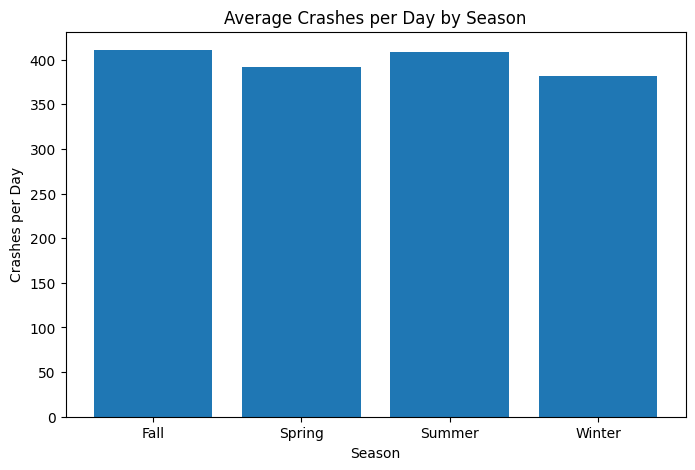

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(season_stats["season"], season_stats["crashes_per_day"])

plt.title("Average Crashes per Day by Season")
plt.xlabel("Season")
plt.ylabel("Crashes per Day")

plt.show()

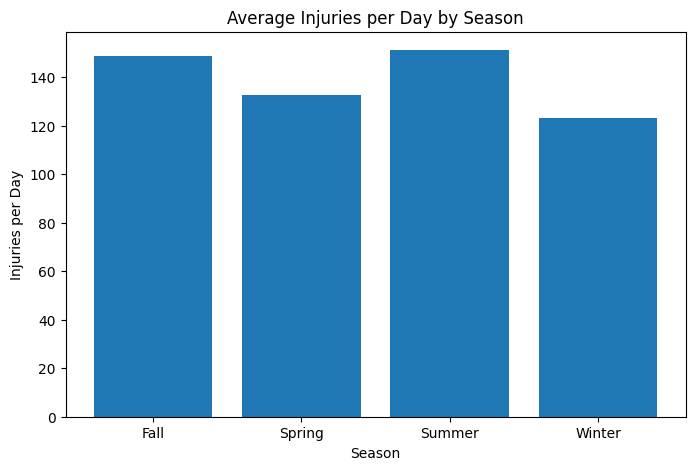

In [47]:
plt.figure(figsize=(8,5))

plt.bar(season_stats["season"], season_stats["injuries_per_day"])

plt.title("Average Injuries per Day by Season")
plt.xlabel("Season")
plt.ylabel("Injuries per Day")

plt.show()